In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error

plt.style.use('default')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('dataset.csv')
df.head()

,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,NIFTY27JAN2626000CE,NIFTY27JAN2626100CE,NIFTY27JAN2626200CE,NIFTY27JAN2626300CE,NIFTY27JAN2626400CE,NIFTY27JAN2626500CE,NIFTY27JAN2623800PE,NIFTY27JAN2623900PE,NIFTY27JAN2624000PE,NIFTY27JAN2624100PE,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,07-01-2026 09:15,26111.65,0.12662,0.12330,0.11741,NaN,0.11005,0.10576,NaN,0.09724,0.09570,0.09397,0.09187,0.09041,0.08908,0.08795,0.17840,0.17237,0.16928,NaN,0.15760,0.15240,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,07-01-2026 09:20,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,0.09837,0.09619,0.09413,0.09236,0.09057,0.08925,0.17962,0.17477,NaN,0.16534,NaN,0.15420,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,07-01-2026 09:25,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,0.08996,0.08861,0.08697,0.08627,0.08541,NaN,0.18010,0.17574,0.17154,0.16567,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN
3,07-01-2026 09:30,26128.95,0.10860,0.10842,0.11150,0.12248,0.10715,0.11098,0.10345,NaN,0.09864,0.09511,0.09304,0.09123,NaN,0.08843,0.18174,NaN,0.17206,0.16502,0.15755,NaN,0.14691,0.14209,0.13721,0.13184,0.12722,0.12252,0.11729,0.11200
4,07-01-2026 09:35,26131.90,0.10462,0.10538,0.12459,0.12051,0.11225,0.11294,0.10544,NaN,0.09896,NaN,0.09412,0.09136,0.09014,0.08885,0.18193,NaN,0.17226,0.16522,0.15924,0.15334,0.14784,0.14230,NaN,0.13219,0.12733,0.12295,0.11707,NaN


In [3]:
print(df.shape)

df.info()

df.describe()

(975, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 975 entries, 0 to 974
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datetime             975 non-null    object 
 1   underlying_price     975 non-null    float64
 2   NIFTY27JAN2625200CE  781 non-null    float64
 3   NIFTY27JAN2625300CE  791 non-null    float64
 4   NIFTY27JAN2625400CE  773 non-null    float64
 5   NIFTY27JAN2625500CE  794 non-null    float64
 6   NIFTY27JAN2625600CE  795 non-null    float64
 7   NIFTY27JAN2625700CE  774 non-null    float64
 8   NIFTY27JAN2625800CE  765 non-null    float64
 9   NIFTY27JAN2625900CE  793 non-null    float64
 10  NIFTY27JAN2626000CE  794 non-null    float64
 11  NIFTY27JAN2626100CE  792 non-null    float64
 12  NIFTY27JAN2626200CE  766 non-null    float64
 13  NIFTY27JAN2626300CE  788 non-null    float64
 14  NIFTY27JAN2626400CE  762 non-null    float64
 15  NIFTY27JAN2626500CE  791 non-n

,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,NIFTY27JAN2626000CE,NIFTY27JAN2626100CE,NIFTY27JAN2626200CE,NIFTY27JAN2626300CE,NIFTY27JAN2626400CE,NIFTY27JAN2626500CE,NIFTY27JAN2623800PE,NIFTY27JAN2623900PE,NIFTY27JAN2624000PE,NIFTY27JAN2624100PE,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
count,975.000000,781.000000,791.000000,773.000000,794.000000,795.000000,774.000000,765.000000,793.000000,794.000000,792.000000,766.000000,788.000000,762.000000,791.000000,772.000000,774.000000,766.000000,799.000000,758.000000,786.000000,773.000000,780.000000,777.000000,800.000000,766.000000,780.000000,780.000000,770.000000
mean,25564.155846,0.140259,0.138818,0.138240,0.142228,0.146016,0.152041,0.160795,0.166556,0.170306,0.184265,0.189361,0.195148,0.195159,0.218350,0.274608,0.267886,0.245142,0.244990,0.230603,0.222443,0.207041,0.191752,0.179123,0.166007,0.154250,0.141069,0.136577,0.126154
std,317.642518,0.068745,0.075571,0.090462,0.113038,0.141846,0.170909,0.198059,0.222128,0.228303,0.264587,0.299639,0.282702,0.275301,0.343940,0.288311,0.322412,0.287086,0.289143,0.266993,0.249447,0.222475,0.190352,0.165855,0.135587,0.111492,0.069741,0.071401,0.052776
min,24940.700000,0.016800,0.063170,0.074030,0.080590,0.081800,0.084060,0.085290,0.086000,0.084500,0.083860,0.083680,0.082690,0.082620,0.082220,0.171050,0.164420,0.162330,0.153920,0.149040,0.142520,0.134770,0.127890,0.116180,0.107260,0.101750,0.096340,0.089750,0.081910
25%,25266.850000,0.111710,0.110250,0.107390,0.105467,0.103865,0.102455,0.100830,0.099050,0.097935,0.096425,0.096592,0.097627,0.099145,0.101725,0.184890,0.178192,0.174255,0.168145,0.161523,0.155110,0.148590,0.142550,0.136040,0.130223,0.125075,0.119525,0.114673,0.109355
50%,25624.200000,0.122760,0.118660,0.114480,0.112460,0.109560,0.107620,0.106660,0.106850,0.107955,0.108015,0.107245,0.111270,0.114510,0.117300,0.196910,0.191870,0.186355,0.180250,0.171725,0.164835,0.157020,0.149170,0.141580,0.135060,0.128905,0.123640,0.118800,0.113695
75%,25768.200000,0.135670,0.128930,0.124020,0.121012,0.118900,0.117575,0.120410,0.125320,0.135595,0.141213,0.150867,0.159550,0.167310,0.176390,0.224483,0.213778,0.203095,0.193290,0.183098,0.174737,0.164270,0.156512,0.148150,0.140690,0.134568,0.128752,0.123983,0.118760
max,26183.800000,0.548960,0.577860,0.731570,1.139080,1.532590,1.916340,2.292520,2.662460,3.027050,2.655700,3.742590,2.506440,2.380210,3.690760,3.172010,5.384760,4.974530,4.593390,4.211720,3.829270,3.445750,3.060780,2.673900,2.284440,1.891510,0.755340,1.088710,0.592490


In [4]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
NIFTY27JAN2624200PE,217
NIFTY27JAN2626400CE,213
NIFTY27JAN2625800CE,210
NIFTY27JAN2626200CE,209
NIFTY27JAN2624800PE,209
NIFTY27JAN2624000PE,209
NIFTY27JAN2625100PE,205
NIFTY27JAN2623800PE,203
NIFTY27JAN2625400CE,202
NIFTY27JAN2624400PE,202


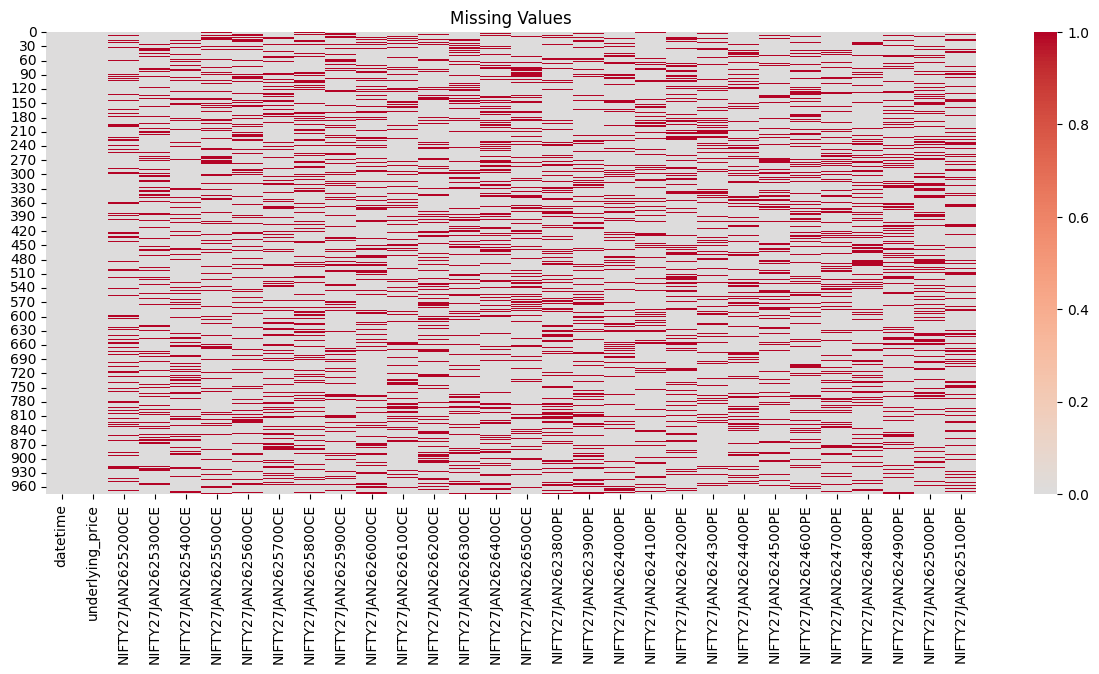

In [5]:
plt.figure(figsize=(15,6))

sns.heatmap(df.isnull(), cmap ='coolwarm', center =0)

plt.title("Missing Values")
plt.show()

In [6]:
ce_cols = [col for col in df.columns if col.endswith('CE')]

pe_cols = [col for col in df.columns if col.endswith('PE')]

print(len(ce_cols))
print(len(pe_cols))

14
14


In [7]:
ce_cols_sorted = sorted(ce_cols, key = lambda x: int(x[12:17]))
pe_cols_sorted = sorted(pe_cols, key = lambda x: int(x[12:17]))

print(ce_cols_sorted)
print(pe_cols_sorted)

['NIFTY27JAN2625200CE', 'NIFTY27JAN2625300CE', 'NIFTY27JAN2625400CE', 'NIFTY27JAN2625500CE', 'NIFTY27JAN2625600CE', 'NIFTY27JAN2625700CE', 'NIFTY27JAN2625800CE', 'NIFTY27JAN2625900CE', 'NIFTY27JAN2626000CE', 'NIFTY27JAN2626100CE', 'NIFTY27JAN2626200CE', 'NIFTY27JAN2626300CE', 'NIFTY27JAN2626400CE', 'NIFTY27JAN2626500CE']
['NIFTY27JAN2623800PE', 'NIFTY27JAN2623900PE', 'NIFTY27JAN2624000PE', 'NIFTY27JAN2624100PE', 'NIFTY27JAN2624200PE', 'NIFTY27JAN2624300PE', 'NIFTY27JAN2624400PE', 'NIFTY27JAN2624500PE', 'NIFTY27JAN2624600PE', 'NIFTY27JAN2624700PE', 'NIFTY27JAN2624800PE', 'NIFTY27JAN2624900PE', 'NIFTY27JAN2625000PE', 'NIFTY27JAN2625100PE']


In [8]:

df_ce = df[['datetime', 'underlying_price']+ ce_cols_sorted]
df_pe = df[['datetime', 'underlying_price']+ pe_cols_sorted]

In [9]:
#definng a function to get strike and compute moneyness
def get_strike(col):
    return int(col[12:17])

def get_moneyness(col, dataframe):
    strike = get_strike(col)
    result = strike / dataframe['underlying_price']
    result.name = 'moneyness'+col
    return result

In [10]:
get_moneyness('NIFTY27JAN2624600PE', df_pe)

,moneynessNIFTY27JAN2624600PE
0,0.942108
1,0.941036
2,0.941110
3,0.941484
4,0.941378
...,...
970,0.978729
971,0.977939
972,0.977166
973,0.976264


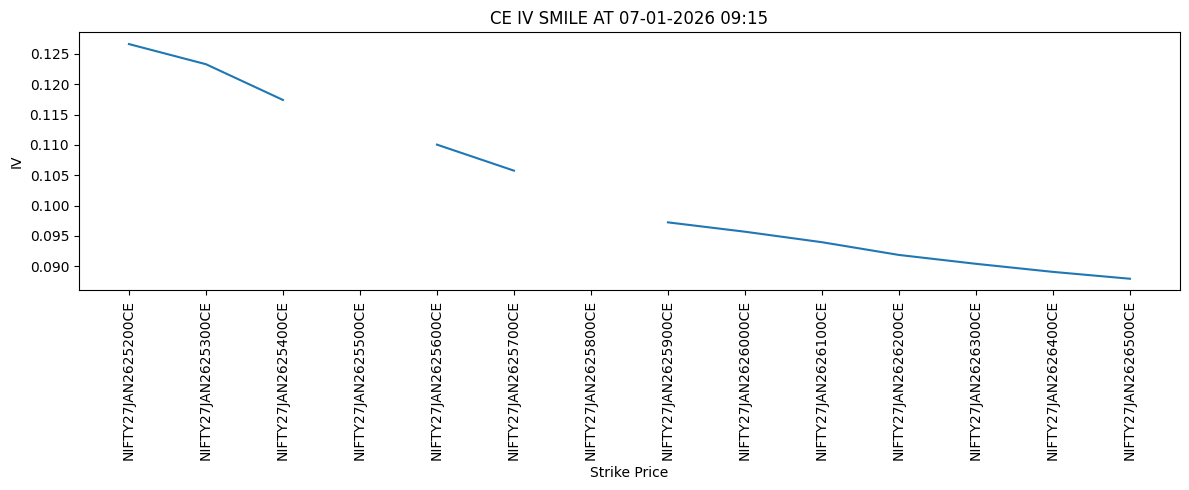

In [11]:
row_ce = df_ce.iloc[0]
plt.figure(figsize=(12,5))
cols = df_ce.drop(columns = ['datetime', 'underlying_price']).columns
plt.xticks(rotation = 90)
plt.plot(cols, row_ce[cols].values)
plt.title(f"CE IV SMILE AT {row_ce['datetime']}")
plt.xlabel("Strike Price")
plt.ylabel("IV")
plt.tight_layout()
plt.show()

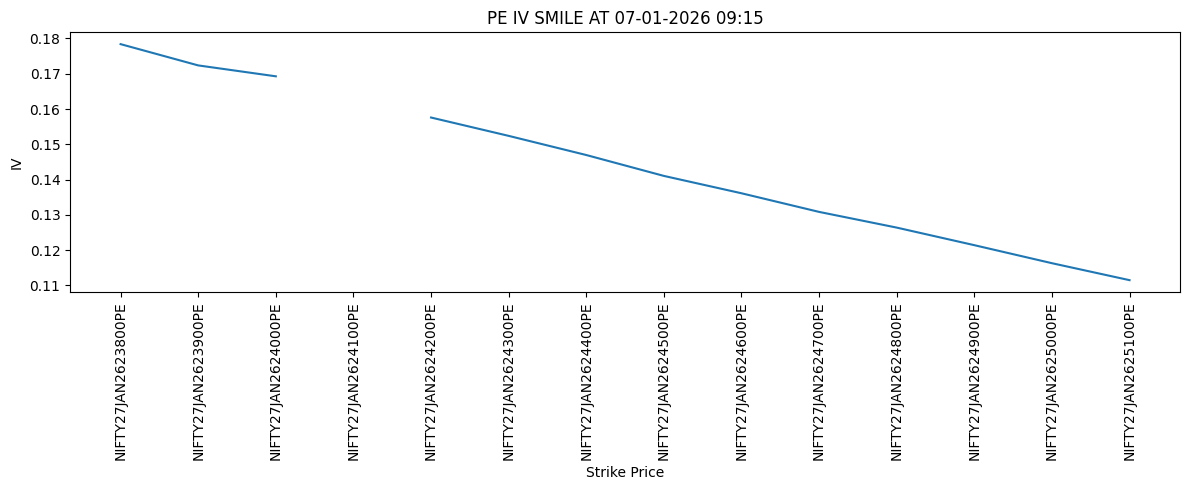

In [12]:
row_pe = df_pe.iloc[0]
plt.figure(figsize=(12,5))
cols = df_pe.drop(columns = ['datetime', 'underlying_price']).columns
plt.xticks(rotation = 90)
plt.plot(cols, row_pe[cols].values)
plt.title(f"PE IV SMILE AT {row_pe['datetime']}")
plt.xlabel("Strike Price")
plt.ylabel("IV")
plt.tight_layout()
plt.show()

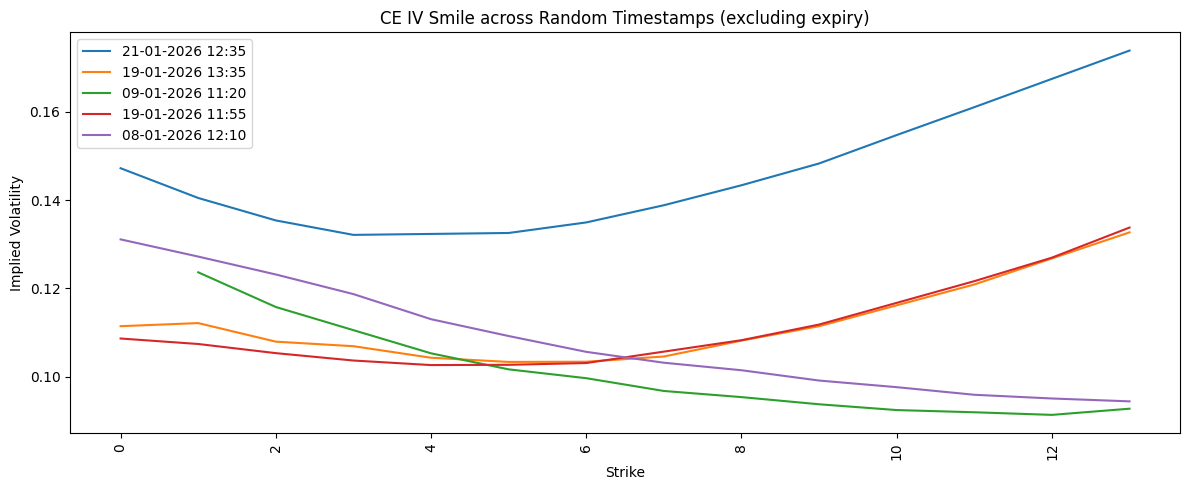

In [13]:
df_ce_normal = df_ce[~df_ce['datetime'].str.startswith('27-01-2026').reset_index(drop=True)]

random_rows = np.random.choice(len(df_ce_normal), size=5, replace=False)

plt.figure(figsize=(12, 5))
for i in random_rows:
    row = df_ce_normal.iloc[i]
    valid = row[ce_cols_sorted].dropna()
    x_positions = [ce_cols_sorted.index(col) for col in valid.index]
    plt.plot(x_positions, valid.values, label=row['datetime'])

plt.title("CE IV Smile across Random Timestamps (excluding expiry)")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

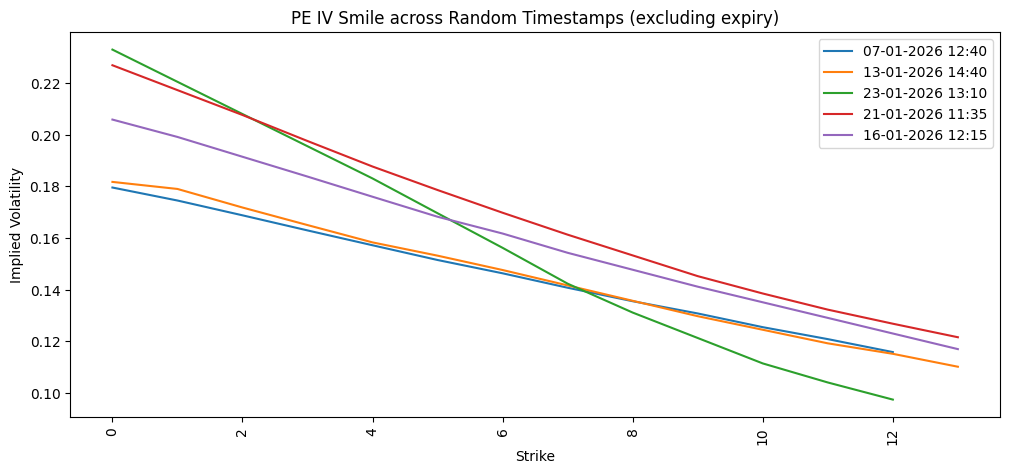

In [14]:
df_pe_normal = df_pe[~df_pe['datetime'].str.startswith('27-01-2026')]

random_rows = np.random.choice(len(df_pe_normal), size = 5, replace = False)

plt.figure(figsize=(12,5))
for i in random_rows:
  row = df_pe_normal.iloc[i]
  valid = row[pe_cols_sorted].dropna()
  x_positions = [pe_cols_sorted.index(col) for col in valid.index]
  plt.plot(x_positions, valid.values,label=row['datetime'])

plt.title("PE IV Smile across Random Timestamps (excluding expiry)")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.xticks(rotation=90)
plt.legend()
plt.show()

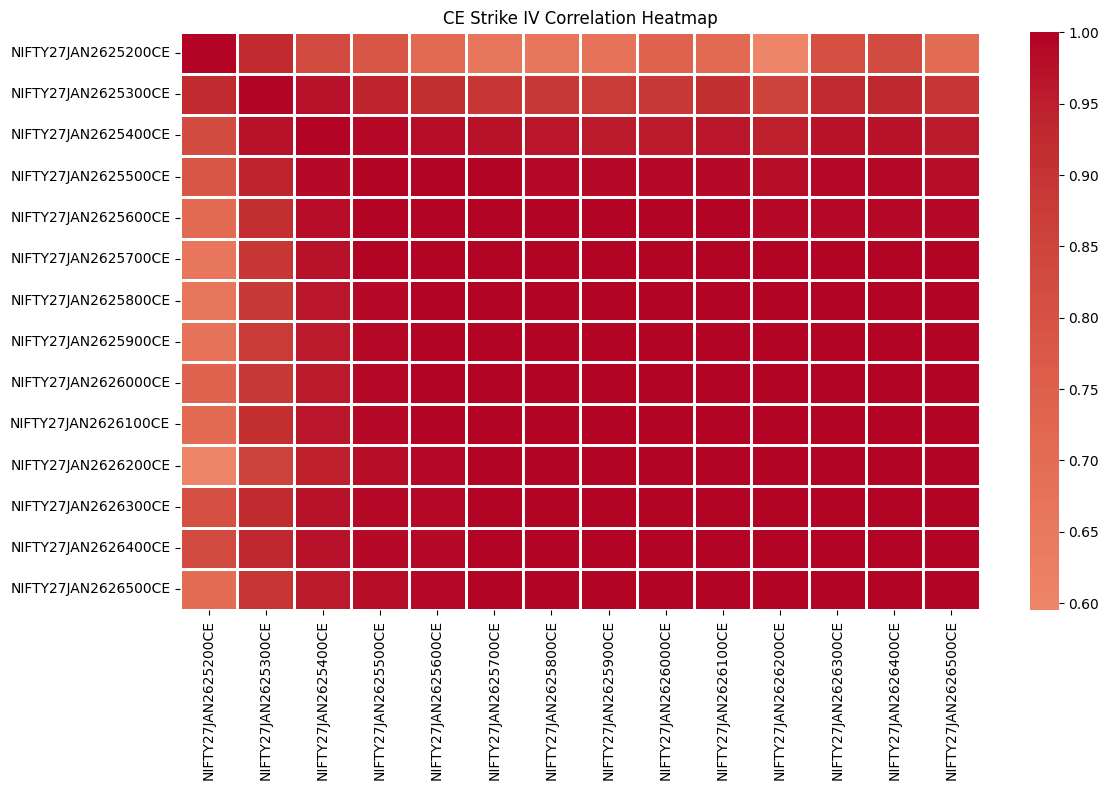

In [15]:
#Plotting correlation heatmaps between the ce columns
plt.figure(figsize=(12,8))
ce_corr = df_ce[ce_cols_sorted].corr()
sns.heatmap(ce_corr, linecolor = 'white', linewidth = 2,cmap = 'coolwarm', center = 0)
plt.title("CE Strike IV Correlation Heatmap")
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

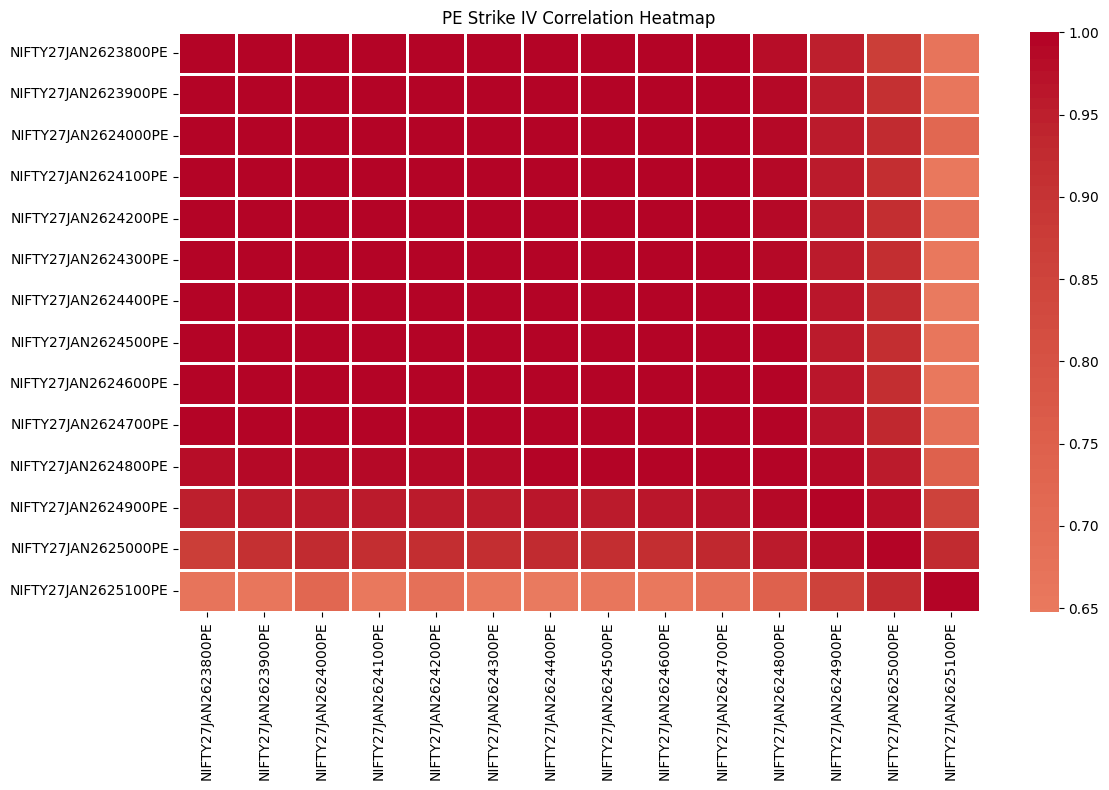

In [16]:
#Plotting correlation heatmaps between the pe columns
plt.figure(figsize=(12,8))
pe_corr = df_pe[pe_cols_sorted].corr()
sns.heatmap(pe_corr, linecolor ='white', linewidth = 2, cmap = 'coolwarm', center = 0)
plt.title("PE Strike IV Correlation Heatmap")
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()



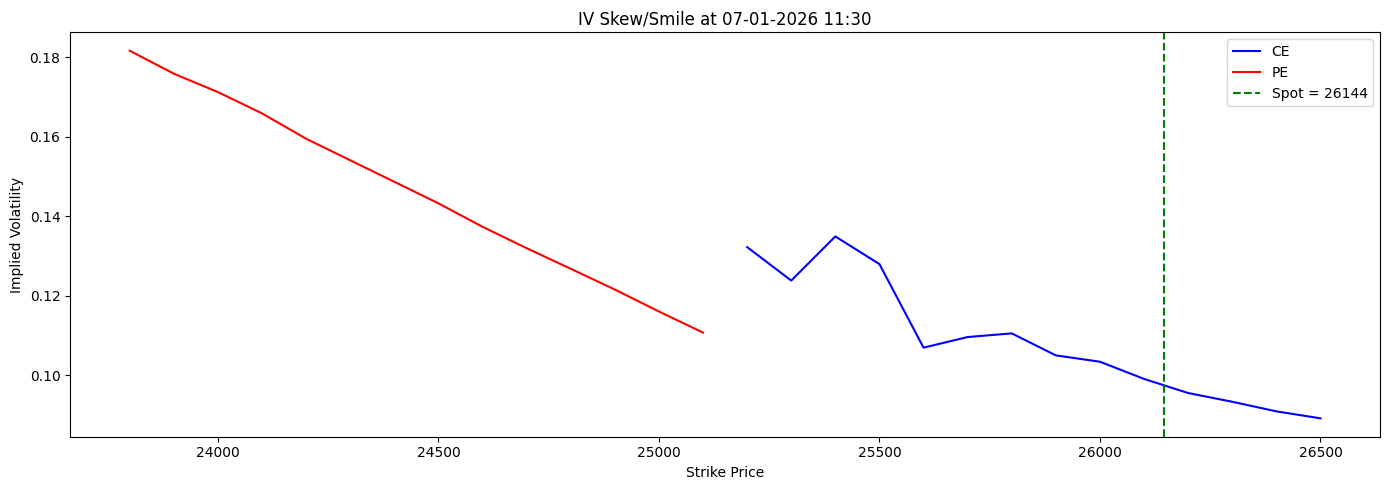

In [17]:
# Pick one clean timestamp with most values present
best_row_idx = df_ce_normal[ce_cols_sorted].notna().sum(axis=1).idxmax()
best_row = df_ce_normal.loc[best_row_idx]

plt.figure(figsize=(14, 5))

# CE
valid_ce = best_row[ce_cols_sorted].dropna()
x_ce = [get_strike(c) for c in valid_ce.index]
plt.plot(x_ce, valid_ce.values, color='blue', label='CE')

# PE on same plot
best_row_pe = df_pe[~df_pe['datetime'].str.startswith('27-01-2026')].loc[best_row_idx] \
    if best_row_idx in df_pe.index else df_pe.iloc[0]
valid_pe = best_row_pe[pe_cols_sorted].dropna()
x_pe = [get_strike(c) for c in valid_pe.index]
plt.plot(x_pe, valid_pe.values, color='red', label='PE')

# Mark ATM
spot = best_row['underlying_price']
plt.axvline(x=spot, color='green', linestyle='--', label=f'Spot = {spot:.0f}')

plt.title(f"IV Skew/Smile at {best_row['datetime']}")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
import pandas as pd
import numpy as np
from scipy.interpolate import Akima1DInterpolator

df_original = pd.read_csv('dataset.csv')

feature_cols = [c for c in df_original.columns if c not in ['datetime', 'underlying_price']]
ce_cols_sorted = sorted([c for c in feature_cols if c.endswith('CE')], key=lambda x: int(x[12:-2]))
pe_cols_sorted = sorted([c for c in feature_cols if c.endswith('PE')], key=lambda x: int(x[12:-2]))

def get_strike(col):
    return int(col[12:-2])

filled_df = df_original.copy()

for idx in df_original.index:
    spot = df_original.loc[idx, 'underlying_price']
    for cols_sorted in [ce_cols_sorted, pe_cols_sorted]:
        is_ce = (cols_sorted == ce_cols_sorted)
        row = df_original.loc[idx, cols_sorted]
        known = row.dropna()
        if len(known) < 3:
            continue
        strikes = np.array([get_strike(c) for c in known.index])
        values = known.values.astype(float)
        all_strikes = np.array([get_strike(c) for c in cols_sorted])
        log_m_known = np.log(strikes / spot)
        log_m_all   = np.log(all_strikes / spot)
        f = Akima1DInterpolator(log_m_known, values, extrapolate=False)
        interpolated = f(log_m_all)
        n = min(4, len(log_m_known) - 1)
        if is_ce:
            left_slope  = (values[1] - values[0]) / (log_m_known[1] - log_m_known[0])
            right_slope = np.polyfit(log_m_known[-n:], values[-n:], 1)[0]
        else:
            left_slope  = np.polyfit(log_m_known[:n], values[:n], 1)[0]
            right_slope = (values[-1] - values[-2]) / (log_m_known[-1] - log_m_known[-2])
        for i, lm in enumerate(log_m_all):
            if np.isnan(interpolated[i]):
                if lm < log_m_known[0]:
                    interpolated[i] = values[0] + left_slope * (lm - log_m_known[0])
                elif lm > log_m_known[-1]:
                    interpolated[i] = values[-1] + right_slope * (lm - log_m_known[-1])
        filled_df.loc[idx, cols_sorted] = interpolated

for col in feature_cols:
    if filled_df[col].isna().any():
        filled_df[col] = filled_df[col].interpolate(method='akima')
        filled_df[col] = filled_df[col].interpolate(method='linear', limit_direction='both')

filled_df[ce_cols_sorted] = filled_df[ce_cols_sorted].clip(lower=0.05)
filled_df[pe_cols_sorted] = filled_df[pe_cols_sorted].clip(lower=0.05)

print("Remaining NaNs:", filled_df.isna().sum().sum())
filled_df.to_csv('filled_dataset.csv', index=False)
print("Saved filled_dataset.csv")

Remaining NaNs: 0
Saved filled_dataset.csv


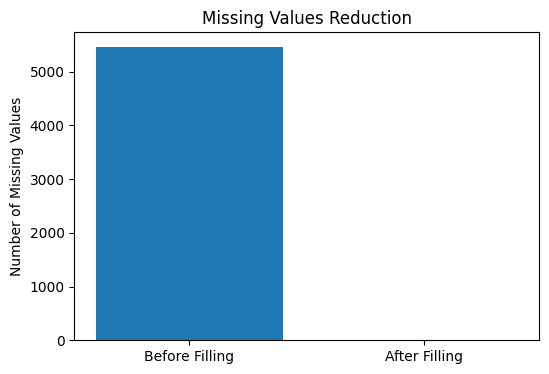

In [26]:
before = df_original.isna().sum().sum()
after = filled_df.isna().sum().sum()

plt.figure(figsize=(6,4))
plt.bar(['Before Filling', 'After Filling'], [before, after])
plt.ylabel('Number of Missing Values')
plt.title('Missing Values Reduction')
plt.show()

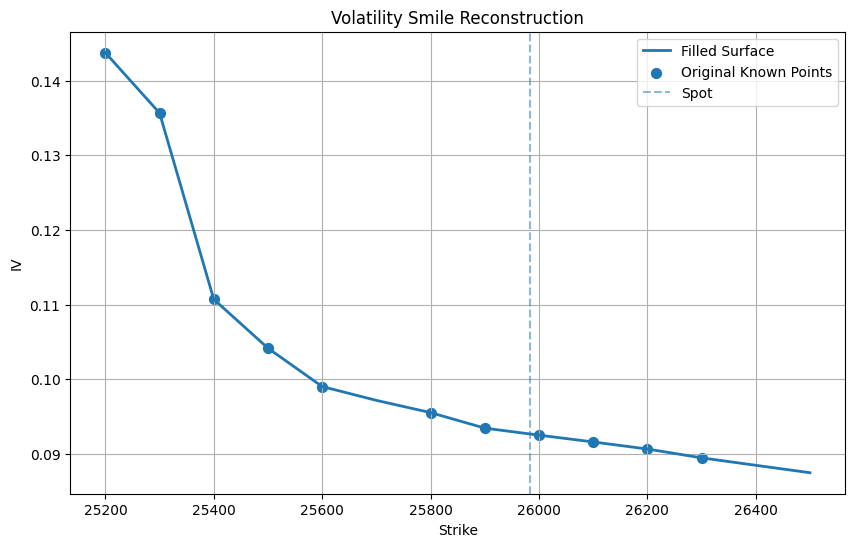

In [27]:
row_idx = 100   # choose any row

spot = filled_df.loc[row_idx, 'underlying_price']

ce_cols = ce_cols_sorted

strikes = np.array([get_strike(c) for c in ce_cols])

original = df_original.loc[row_idx, ce_cols]
filled = filled_df.loc[row_idx, ce_cols]

plt.figure(figsize=(10,6))

plt.plot(strikes,filled,label='Filled Surface',linewidth=2)

plt.scatter(strikes[~original.isna()],original.dropna(),label='Original Known Points',s=50)

plt.axvline(spot, linestyle='--', alpha=0.5, label='Spot')

plt.xlabel('Strike')
plt.ylabel('IV')
plt.title('Volatility Smile Reconstruction')
plt.legend()
plt.grid(True)

plt.show()

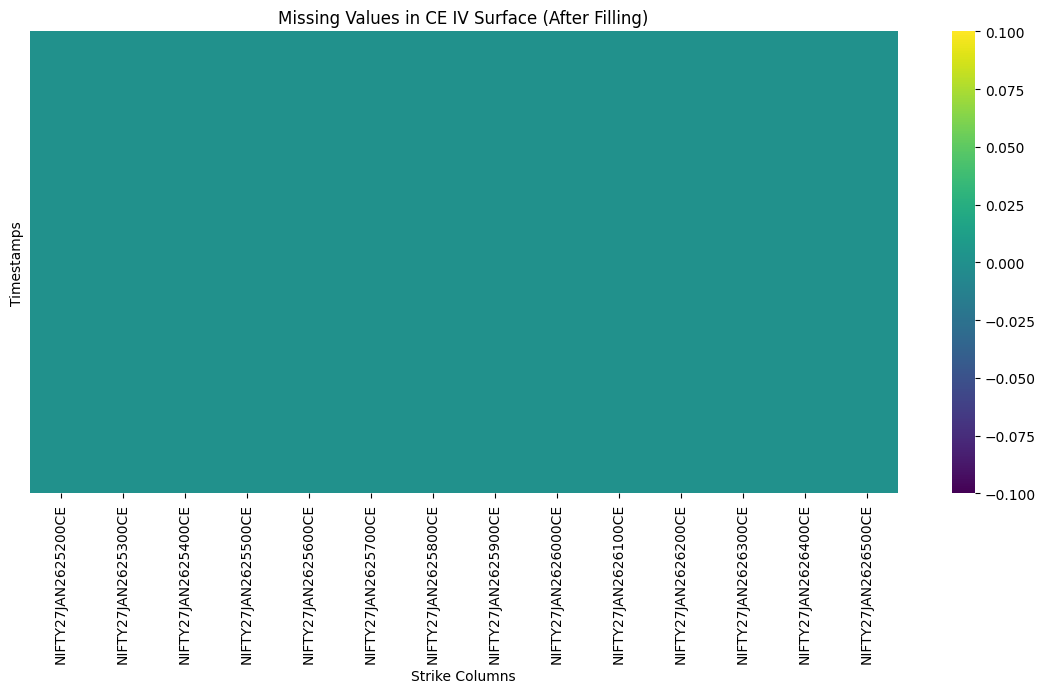

In [29]:
plt.figure(figsize=(14,6))

sns.heatmap(filled_df[ce_cols_sorted].isna(),cmap='viridis',cbar=True, yticklabels=False)

plt.title("Missing Values in CE IV Surface (After Filling)")
plt.xlabel("Strike Columns")
plt.ylabel("Timestamps")

plt.show()